In [1]:
import torch
import numpy as np

In [42]:
from remdo.problems import Satellite
from remdo.gp import train_multitask_gp
from remdo.acquisition import multitask_acquisition, optimize_acquisition
from remdo.active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

sat_prob = Satellite()
gpmodel = train_multitask_gp(sat_prob, num_train=100, seed=9999) 

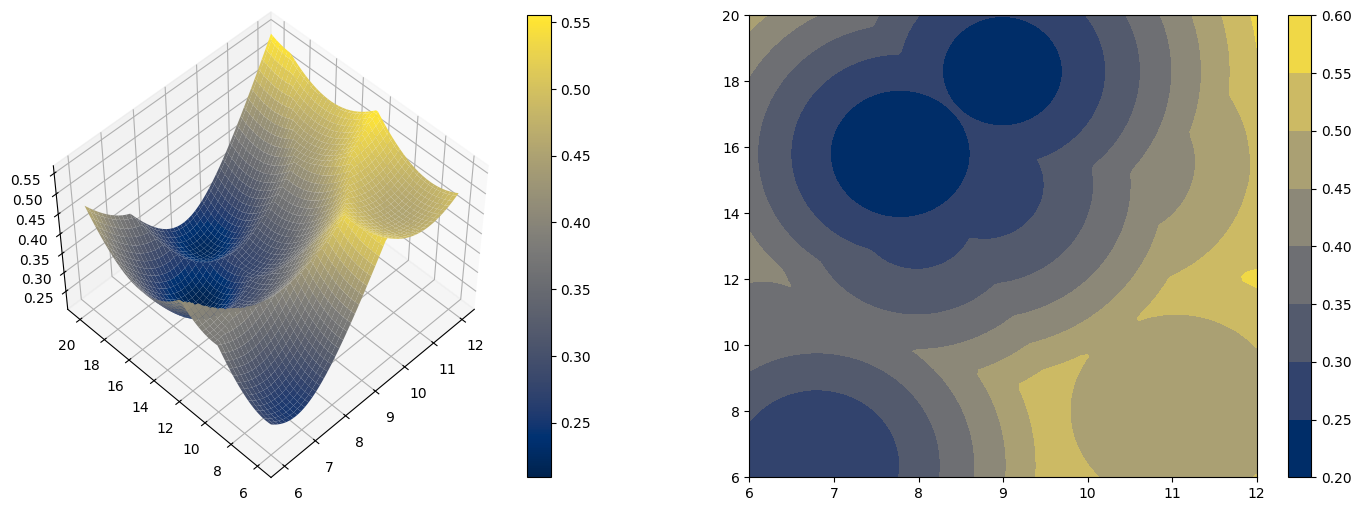

In [69]:
# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[1,...]) # use input from above
input_vec = torch.rand(5)*2 # random input
npts = 100

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# x_input = torch.tensor([ 0.0466,  1.2396,  0.1535,  1.4766,  1.3618 ]).repeat(npts**2,1)
x_input = torch.ones(1,5).repeat(npts**2,1)
test_input = torch.column_stack((x_input, xvec.reshape(-1,1), yvec.reshape(-1,1)))
x_input_norm = torch.column_stack((normalize(test_input, bounds), torch.zeros(npts**2)))

from remdo.acquisition import maximin
min_dists = maximin(x_input_norm, mt_model)

# print(min_dists)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18,6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.view_init(elev=50,azim=-135)

surf1 = ax1.plot_surface(xvec, yvec, min_dists.reshape(npts,npts), cmap='cividis')
plt.colorbar(surf1)

ax2 = fig.add_subplot(122)
cf2 = ax2.contourf(xvec, yvec, min_dists.reshape(npts,npts), cmap='cividis')
plt.colorbar(cf2)